In [133]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

In [134]:
df_canais_venda = pd.read_csv('canais de venda auditado.csv', sep=';', decimal=',')
df_clientes = pd.read_csv('Clientes auditado.csv', sep=';', decimal=',')
df_funcionarios = pd.read_csv('Funcionarios auditado.csv', sep=';', decimal=',')
df_reservas = pd.read_csv('Reservas auditado.csv', sep=';', decimal=',')
df_tipos_quarto = pd.read_csv('Tipos de Quarto auditado.csv', sep=';', decimal=',')
df_unidades = pd.read_csv('Unidades auditado.csv', sep=';', decimal=',')

In [135]:
df_tipos_quarto['valor_diaria_base'] = pd.to_numeric(
    df_tipos_quarto['valor_diaria_base']
)

df_reservas['data_checkin'] = pd.to_datetime(
    df_reservas['data_checkin']
)

df_reservas['data_checkout'] = pd.to_datetime(
    df_reservas['data_checkout']
)

# Problema 1

## Pergunta de Negócio

A diretoria quer entender o comportamento das diárias praticadas na rede e a distribuição do faturamento entre as unidades. O que os dados revelam?

*Nesta análise serão avaliadas as diárias praticadas pelas unidades da rede, bem como a distribuição do faturamento gerado por cada uma delas. O objetivo é identificar padrões de precificação, concentração de receita e possíveis diferenças de desempenho entre as unidades.*

In [136]:
## Criando a base analítica

df_analise = (df_reservas.merge(df_tipos_quarto, on='id_tipo_quarto', how='left')
    .merge(df_unidades, on='id_unidade', how='left'))

## Criando coluna de Faturamento

df_analise['faturamento'] = df_analise['qtd_diarias'] * df_analise['valor_diaria_base']

df_analise

,id_reserva,id_unidade,id_tipo_quarto,id_cliente,id_canal,data_checkin,data_checkout,qtd_diarias,num_hospedes,avaliacao_hospede,...,forma_pagamento,descricao,capacidade_max,valor_diaria_base,nome_unidade,cidade,regiao,categoria_hotel,num_quartos_total,faturamento
0,1,5,1,3,2.0,2024-04-28,2024-04-30,2,1,4.0,...,Cartão De Crédito,Standard,2,280.0,NaraHoteis Nova Iguaçu Centro,Nova Iguaçu,Baixada Fluminense,3 Estrelas,50,560.0
1,2,5,1,261,4.0,2023-09-28,2023-10-01,3,2,1.0,...,Pix,Standard,2,280.0,NaraHoteis Nova Iguaçu Centro,Nova Iguaçu,Baixada Fluminense,3 Estrelas,50,840.0
2,3,10,4,49,4.0,2023-08-01,2023-08-06,5,1,9.0,...,Cartão De Crédito,Suite,4,950.0,NaraHoteis Paraty,Paraty,Costa Verde,5 Estrelas,65,4750.0
3,4,6,2,23,2.0,2023-02-18,2023-02-21,3,1,9.0,...,Pix,Superior,2,420.0,NaraHoteis Nova Iguaçu Park,Nova Iguaçu,Baixada Fluminense,3 Estrelas,55,1260.0
4,5,7,1,42,1.0,2023-01-12,2023-01-19,7,1,6.0,...,Transferência,Standard,2,280.0,NaraHoteis Petrópolis,Petrópolis,Serra,5 Estrelas,70,1960.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2452,2453,10,3,210,4.0,2023-10-22,2023-10-27,5,1,9.0,...,Cartão De Débito,Deluxe,3,580.0,NaraHoteis Paraty,Paraty,Costa Verde,5 Estrelas,65,2900.0
2453,2454,7,3,271,2.0,2024-08-08,2024-08-14,6,2,6.0,...,Pix,Deluxe,3,580.0,NaraHoteis Petrópolis,Petrópolis,Serra,5 Estrelas,70,3480.0
2454,2455,7,1,143,1.0,2023-07-26,2023-07-27,1,2,6.0,...,Transferência,Standard,2,280.0,NaraHoteis Petrópolis,Petrópolis,Serra,5 Estrelas,70,280.0
2455,2456,8,4,176,1.0,2023-05-10,2023-05-17,7,1,6.0,...,Cartão De Débito,Suite,4,950.0,NaraHoteis Teresópolis,Teresópolis,Serra,4 Estrelas,60,6650.0


In [137]:
## Comportamento das diárias praticadas na rede

display(df_tipos_quarto['valor_diaria_base'].describe())

df_tipos_quarto[
    ['descricao',
     'valor_diaria_base',
     'capacidade_max']
]

count       5.000000
mean      746.000000
std       490.183639
min       280.000000
25%       420.000000
50%       580.000000
75%       950.000000
max      1500.000000
Name: valor_diaria_base, dtype: float64

,descricao,valor_diaria_base,capacidade_max
0,Standard,280.0,2
1,Superior,420.0,2
2,Deluxe,580.0,3
3,Suite,950.0,4
4,Suíte Master,1500.0,4


In [138]:
fat_unidade = (
    df_analise
    .groupby('nome_unidade')['faturamento']
    .sum()
    .sort_values(ascending=False)
)

fat_unidade_pct = (
    fat_unidade
    / fat_unidade.sum()
) * 100

fat_unidade_pct.round(2)

nome_unidade
NaraHoteis Paraty                10.24
NaraHoteis Friburgo               9.85
NaraHoteis Teresópolis            9.60
NaraHoteis Nova Iguaçu Park       9.59
NaraHoteis Santa Teresa           9.57
NaraHoteis Petrópolis             9.35
NaraHoteis Barra da Tijuca        9.08
NaraHoteis Mangaratiba            8.97
NaraHoteis Angra dos Reis         8.51
NaraHoteis Ipanema                8.21
NaraHoteis Centro                 3.75
NaraHoteis Nova Iguaçu Centro     3.27
Name: faturamento, dtype: float64

In [139]:
fat_unidade = (
    df_analise
    .groupby(['nome_unidade', 'num_quartos_total'])['faturamento']
    .sum()
    .reset_index()
)

fat_unidade.sort_values(
    'faturamento',
    ascending=False
)

,nome_unidade,num_quartos_total,faturamento
8,NaraHoteis Paraty,65,532920.0
3,NaraHoteis Friburgo,55,512630.0
11,NaraHoteis Teresópolis,60,499150.0
7,NaraHoteis Nova Iguaçu Park,55,498930.0
10,NaraHoteis Santa Teresa,45,498020.0
9,NaraHoteis Petrópolis,70,486200.0
1,NaraHoteis Barra da Tijuca,120,472200.0
5,NaraHoteis Mangaratiba,50,466860.0
0,NaraHoteis Angra dos Reis,90,442810.0
4,NaraHoteis Ipanema,80,427080.0


In [140]:
fat_unidade = (
    df_analise
    .groupby(
        ['nome_unidade', 'num_quartos_total']
    )['faturamento']
    .sum()
    .reset_index()
)

##Arredondar apenas na visualização:

fat_unidade['receita_por_quarto'] = (
    fat_unidade['faturamento']
    / fat_unidade['num_quartos_total']
)

fat_unidade.sort_values(
    'receita_por_quarto',
    ascending=False
).round(2)

,nome_unidade,num_quartos_total,faturamento,receita_por_quarto
10,NaraHoteis Santa Teresa,45,498020.0,11067.11
5,NaraHoteis Mangaratiba,50,466860.0,9337.20
3,NaraHoteis Friburgo,55,512630.0,9320.55
7,NaraHoteis Nova Iguaçu Park,55,498930.0,9071.45
11,NaraHoteis Teresópolis,60,499150.0,8319.17
8,NaraHoteis Paraty,65,532920.0,8198.77
9,NaraHoteis Petrópolis,70,486200.0,6945.71
4,NaraHoteis Ipanema,80,427080.0,5338.50
0,NaraHoteis Angra dos Reis,90,442810.0,4920.11
1,NaraHoteis Barra da Tijuca,120,472200.0,3935.00


# Problema 2

## Pergunta de Negócio

Existem unidades operando além de sua capacidade? Quais os impactos disso para o negócio?

*Nesta etapa será analisada a capacidade operacional das unidades em comparação com o volume de reservas realizadas. O objetivo é identificar possíveis casos de superocupação, avaliar seus impactos e entender os riscos operacionais associados.*

In [141]:
## descobrir qual é o período coberto pela base

display(df_reservas['data_checkin'].min())
display(df_reservas['data_checkout'].max())

Timestamp('2023-01-01 00:00:00')

Timestamp('2025-01-06 00:00:00')

In [142]:
## Validando para ver se ta lendo corretamente

validacao = df_reservas.copy()

validacao['dias_calculados'] = (
    validacao['data_checkout']
    - validacao['data_checkin']
).dt.days

display(
    validacao[
        ['data_checkin',
         'data_checkout',
         'qtd_diarias',
         'dias_calculados']
    ]
    .sort_values('dias_calculados')
    .head(20)
)

,data_checkin,data_checkout,qtd_diarias,dias_calculados
44,2024-02-20,2024-02-21,1,1
2432,2024-06-30,2024-07-01,1,1
2454,2023-07-26,2023-07-27,1,1
2136,2024-04-20,2024-04-21,1,1
385,2024-12-20,2024-12-21,1,1
364,2023-04-10,2023-04-11,1,1
360,2024-12-26,2024-12-27,1,1
397,2023-08-13,2023-08-14,1,1
394,2023-08-27,2023-08-28,1,1
393,2024-04-14,2024-04-15,1,1


In [143]:
reservas_expandidas = df_reservas.copy()

reservas_expandidas['data_ocupacao'] = reservas_expandidas.apply(
    lambda linha: pd.date_range(
        start=linha['data_checkin'],
        end=linha['data_checkout'] - pd.Timedelta(days=1),
        freq='D'
    ),
    axis=1
)

reservas_expandidas = reservas_expandidas.explode('data_ocupacao')

display(
    reservas_expandidas[
        [
            'id_reserva',
            'id_unidade',
            'data_checkin',
            'data_checkout',
            'data_ocupacao'
        ]
    ].head(5)
)

,id_reserva,id_unidade,data_checkin,data_checkout,data_ocupacao
0,1,5,2024-04-28,2024-04-30,2024-04-28
0,1,5,2024-04-28,2024-04-30,2024-04-29
1,2,5,2023-09-28,2023-10-01,2023-09-28
1,2,5,2023-09-28,2023-10-01,2023-09-29
1,2,5,2023-09-28,2023-10-01,2023-09-30


In [144]:
ocupacao_diaria = (
    reservas_expandidas
    .groupby(
        [
            'id_unidade',
            'data_ocupacao'
        ]
    )
    .size()
    .reset_index(name='quartos_ocupados')
)

display(ocupacao_diaria.head(20))

,id_unidade,data_ocupacao,quartos_ocupados
0,1,2023-01-05,1
1,1,2023-01-08,1
2,1,2023-01-09,2
3,1,2023-01-10,3
4,1,2023-01-11,3
5,1,2023-01-12,3
6,1,2023-01-13,4
7,1,2023-01-14,3
8,1,2023-01-15,3
9,1,2023-01-16,3


In [145]:
ocupacao_diaria = ocupacao_diaria.merge(
    df_unidades[
        [
            'id_unidade',
            'nome_unidade',
            'num_quartos_total'
        ]
    ],
    on='id_unidade',
    how='left'
)

display(ocupacao_diaria.head())

,id_unidade,data_ocupacao,quartos_ocupados,nome_unidade,num_quartos_total
0,1,2023-01-05,1,NaraHoteis Ipanema,80
1,1,2023-01-08,1,NaraHoteis Ipanema,80
2,1,2023-01-09,2,NaraHoteis Ipanema,80
3,1,2023-01-10,3,NaraHoteis Ipanema,80
4,1,2023-01-11,3,NaraHoteis Ipanema,80


In [146]:
## Calculando taxa de ocupação

ocupacao_diaria['taxa_ocupacao'] = (
    ocupacao_diaria['quartos_ocupados']
    / ocupacao_diaria['num_quartos_total']
)

## Resumo por unidade
## Pegando o maior pico de ocupação registrado

ocupacao_maxima = (
    ocupacao_diaria
    .groupby(
        [
            'id_unidade',
            'nome_unidade',
            'num_quartos_total'
        ]
    )['taxa_ocupacao']
    .max()
    .reset_index()
)

## Convertendo para percentual

ocupacao_maxima['taxa_ocupacao_pct'] = (
    ocupacao_maxima['taxa_ocupacao'] * 100
).round(2)

display(
    ocupacao_maxima[
        [
            'nome_unidade',
            'num_quartos_total',
            'taxa_ocupacao_pct'
        ]
    ]
    .sort_values(
        'taxa_ocupacao_pct',
        ascending=False
    )
)

,nome_unidade,num_quartos_total,taxa_ocupacao_pct
2,NaraHoteis Centro,60,133.33
4,NaraHoteis Nova Iguaçu Centro,50,128.00
3,NaraHoteis Santa Teresa,45,13.33
5,NaraHoteis Nova Iguaçu Park,55,10.91
7,NaraHoteis Teresópolis,60,10.00
11,NaraHoteis Mangaratiba,50,10.00
8,NaraHoteis Friburgo,55,9.09
9,NaraHoteis Paraty,65,7.69
6,NaraHoteis Petrópolis,70,7.14
10,NaraHoteis Angra dos Reis,90,5.56


# Problema 3

## Pergunta de Negócio

Existem unidades com performance de receita discrepante em relação às demais? Como você identificaria, mediria e comprovaria isso?

*Esta análise busca identificar unidades cujo desempenho de receita difere significativamente do restante da rede. Serão utilizadas medidas estatísticas e indicadores de dispersão para identificar, mensurar e comprovar possíveis discrepâncias.*

In [147]:
fat_unidade = (
    df_analise
    .groupby('nome_unidade')['faturamento']
    .sum()
    .reset_index()
)

display(fat_unidade)

## Calculando os Quartis
q1 = fat_unidade['faturamento'].quantile(0.25)
q2 = fat_unidade['faturamento'].quantile(0.50)
q3 = fat_unidade['faturamento'].quantile(0.75)

iqr = q3 - q1

limite_inferior = q1 - (1.5 * iqr)
limite_superior = q3 + (1.5 * iqr)

print(f'Q1: {q1:,.2f}')
print(f'Mediana: {q2:,.2f}')
print(f'Q3: {q3:,.2f}')
print(f'IQR: {iqr:,.2f}')
print(f'Limite Inferior: {limite_inferior:,.2f}')
print(f'Limite Superior: {limite_superior:,.2f}')

,nome_unidade,faturamento
0,NaraHoteis Angra dos Reis,442810.0
1,NaraHoteis Barra da Tijuca,472200.0
2,NaraHoteis Centro,195140.0
3,NaraHoteis Friburgo,512630.0
4,NaraHoteis Ipanema,427080.0
5,NaraHoteis Mangaratiba,466860.0
6,NaraHoteis Nova Iguaçu Centro,169960.0
7,NaraHoteis Nova Iguaçu Park,498930.0
8,NaraHoteis Paraty,532920.0
9,NaraHoteis Petrópolis,486200.0


Q1: 438,877.50
Mediana: 479,200.00
Q3: 498,985.00
IQR: 60,107.50
Limite Inferior: 348,716.25
Limite Superior: 589,146.25


In [148]:
## Outliers

outliers = fat_unidade[
    (fat_unidade['faturamento'] < limite_inferior)
    |
    (fat_unidade['faturamento'] > limite_superior)
]

display(outliers)

,nome_unidade,faturamento
2,NaraHoteis Centro,195140.0
6,NaraHoteis Nova Iguaçu Centro,169960.0


In [149]:
## Visualizar todas as unidades classificadas

fat_unidade['classificacao'] = 'Normal'

fat_unidade.loc[
    fat_unidade['faturamento'] < limite_inferior,
    'classificacao'
] = 'Abaixo do esperado'

fat_unidade.loc[
    fat_unidade['faturamento'] > limite_superior,
    'classificacao'
] = 'Acima do esperado'

display(
    fat_unidade
    .sort_values('faturamento', ascending=False)
)

,nome_unidade,faturamento,classificacao
8,NaraHoteis Paraty,532920.0,Normal
3,NaraHoteis Friburgo,512630.0,Normal
11,NaraHoteis Teresópolis,499150.0,Normal
7,NaraHoteis Nova Iguaçu Park,498930.0,Normal
10,NaraHoteis Santa Teresa,498020.0,Normal
9,NaraHoteis Petrópolis,486200.0,Normal
1,NaraHoteis Barra da Tijuca,472200.0,Normal
5,NaraHoteis Mangaratiba,466860.0,Normal
0,NaraHoteis Angra dos Reis,442810.0,Normal
4,NaraHoteis Ipanema,427080.0,Normal


# Problema 4

## Pergunta de Negócio

Há relação entre o RevPAR das unidades e a avaliação média dos hóspedes? Essa relação é forte o suficiente para sustentar uma análise preditiva?

*O objetivo desta análise é investigar a existência de correlação entre a satisfação dos hóspedes e o desempenho financeiro das unidades, medido pelo RevPAR. Também será avaliada a intensidade dessa relação para verificar seu potencial preditivo.*

In [150]:
## Construindo tabela de receita por unidade

receita_unidade = (
    df_analise
    .groupby('nome_unidade')['faturamento']
    .sum()
    .reset_index()
)

receita_unidade = receita_unidade.merge(
    df_unidades[
        ['nome_unidade', 'num_quartos_total']
    ],
    on='nome_unidade',
    how='left'
)

receita_unidade['receita_por_quarto'] = (
    receita_unidade['faturamento']
    / receita_unidade['num_quartos_total']
)

display(receita_unidade)

,nome_unidade,faturamento,num_quartos_total,receita_por_quarto
0,NaraHoteis Angra dos Reis,442810.0,90,4920.111111
1,NaraHoteis Barra da Tijuca,472200.0,120,3935.000000
2,NaraHoteis Centro,195140.0,60,3252.333333
3,NaraHoteis Friburgo,512630.0,55,9320.545455
4,NaraHoteis Ipanema,427080.0,80,5338.500000
5,NaraHoteis Mangaratiba,466860.0,50,9337.200000
6,NaraHoteis Nova Iguaçu Centro,169960.0,50,3399.200000
7,NaraHoteis Nova Iguaçu Park,498930.0,55,9071.454545
8,NaraHoteis Paraty,532920.0,65,8198.769231
9,NaraHoteis Petrópolis,486200.0,70,6945.714286


In [151]:
## Calculando a média de avaliação por hotel

avaliacao_unidade = (
    df_analise
    .groupby('nome_unidade')['avaliacao_hospede']
    .mean()
    .reset_index()
)

display(avaliacao_unidade)

## Juntando a media com a receita

df_revpar = receita_unidade.merge(
    avaliacao_unidade,
    on='nome_unidade',
    how='left'
)

display(df_revpar)

,nome_unidade,avaliacao_hospede
0,NaraHoteis Angra dos Reis,7.872611
1,NaraHoteis Barra da Tijuca,7.886076
2,NaraHoteis Centro,2.197628
3,NaraHoteis Friburgo,8.029762
4,NaraHoteis Ipanema,8.120253
5,NaraHoteis Mangaratiba,7.795322
6,NaraHoteis Nova Iguaçu Centro,2.215596
7,NaraHoteis Nova Iguaçu Park,7.981818
8,NaraHoteis Paraty,7.813953
9,NaraHoteis Petrópolis,7.982036


,nome_unidade,faturamento,num_quartos_total,receita_por_quarto,avaliacao_hospede
0,NaraHoteis Angra dos Reis,442810.0,90,4920.111111,7.872611
1,NaraHoteis Barra da Tijuca,472200.0,120,3935.000000,7.886076
2,NaraHoteis Centro,195140.0,60,3252.333333,2.197628
3,NaraHoteis Friburgo,512630.0,55,9320.545455,8.029762
4,NaraHoteis Ipanema,427080.0,80,5338.500000,8.120253
5,NaraHoteis Mangaratiba,466860.0,50,9337.200000,7.795322
6,NaraHoteis Nova Iguaçu Centro,169960.0,50,3399.200000,2.215596
7,NaraHoteis Nova Iguaçu Park,498930.0,55,9071.454545,7.981818
8,NaraHoteis Paraty,532920.0,65,8198.769231,7.813953
9,NaraHoteis Petrópolis,486200.0,70,6945.714286,7.982036


In [152]:
## Calculando o Coeficiente Pearson

correlacao = df_revpar[
    ['receita_por_quarto',
     'avaliacao_hospede']
].corr()

display(correlacao)

,receita_por_quarto,avaliacao_hospede
receita_por_quarto,1.000000,0.633707
avaliacao_hospede,0.633707,1.000000


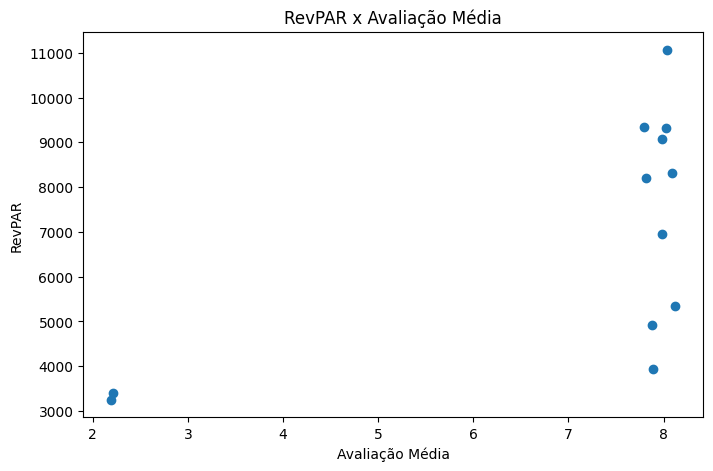

In [153]:
## Grafico de Dispersão

plt.figure(figsize=(8,5))

plt.scatter(
    df_revpar['avaliacao_hospede'],
    df_revpar['receita_por_quarto']
)

plt.xlabel('Avaliação Média')
plt.ylabel('RevPAR')
plt.title('RevPAR x Avaliação Média')

plt.show()

In [154]:
## Calculando a correlação entre RevPAR e avaliação média

corr = df_revpar['receita_por_quarto'].corr(
    df_revpar['avaliacao_hospede']
)

display(f'Correlação: {corr:.3f}')

## Calculando o R²

r2 = corr ** 2

display(f'R²: {r2:.3f}')

'Correlação: 0.634'

'R²: 0.402'

# Problema 5

## Pergunta de Negócio

Com base nos dados históricos, é possível estimar o RevPAR esperado de uma unidade a partir da sua avaliação média? Construa e avalie esse modelo.

*Nesta etapa será desenvolvido um modelo preditivo para estimar o RevPAR utilizando como variável explicativa a avaliação média dos hóspedes. O desempenho do modelo será avaliado por meio de métricas estatísticas apropriadas.*

In [155]:
## Definindo Variaveis

X = df_revpar[['avaliacao_hospede']]

y = df_revpar['receita_por_quarto']

In [156]:
## Criando o modelo

modelo = LinearRegression()

## Treinando o modelo

modelo.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[753.99]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['avaliacao_hospede']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1646
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,1


In [157]:
## Previsões

df_revpar['revpar_previsto'] = modelo.predict(X)

display(df_revpar)

,nome_unidade,faturamento,num_quartos_total,receita_por_quarto,avaliacao_hospede,revpar_previsto
0,NaraHoteis Angra dos Reis,442810.0,90,4920.111111,7.872611,7582.036714
1,NaraHoteis Barra da Tijuca,472200.0,120,3935.000000,7.886076,7592.188775
2,NaraHoteis Centro,195140.0,60,3252.333333,2.197628,3303.167128
3,NaraHoteis Friburgo,512630.0,55,9320.545455,8.029762,7700.526273
4,NaraHoteis Ipanema,427080.0,80,5338.500000,8.120253,7768.755605
5,NaraHoteis Mangaratiba,466860.0,50,9337.200000,7.795322,7523.761105
6,NaraHoteis Nova Iguaçu Centro,169960.0,50,3399.200000,2.215596,3316.714689
7,NaraHoteis Nova Iguaçu Park,498930.0,55,9071.454545,7.981818,7664.377277
8,NaraHoteis Paraty,532920.0,65,8198.769231,7.813953,7537.809298
9,NaraHoteis Petrópolis,486200.0,70,6945.714286,7.982036,7664.541456


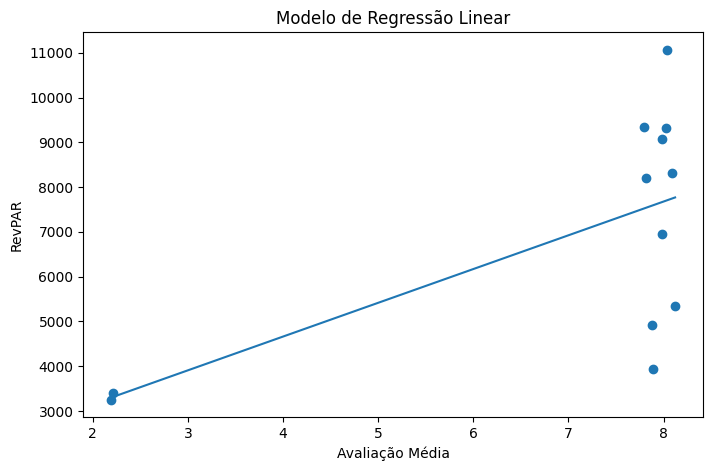

In [158]:
## Grafico

df_plot = df_revpar.sort_values(
    'avaliacao_hospede'
)

plt.figure(figsize=(8,5))

plt.scatter(
    df_plot['avaliacao_hospede'],
    df_plot['receita_por_quarto']
)

plt.plot(
    df_plot['avaliacao_hospede'],
    df_plot['revpar_previsto']
)

plt.xlabel('Avaliação Média')
plt.ylabel('RevPAR')
plt.title('Modelo de Regressão Linear')

plt.show()
plt.show()

In [159]:
df_analise['ano_mes'] = (
    df_analise['data_checkin']
    .dt.to_period('M')
)
receita_mensal = (
    df_analise
    .groupby(
        ['id_unidade', 'ano_mes']
    )['faturamento']
    .sum()
    .reset_index()
)
avaliacao_mensal = (
    df_analise
    .groupby(
        ['id_unidade', 'ano_mes']
    )['avaliacao_hospede']
    .mean()
    .reset_index()
)
df_modelo = receita_mensal.merge(
    avaliacao_mensal,
    on=['id_unidade', 'ano_mes'],
    how='inner'
)
df_modelo = df_modelo.merge(
    df_unidades[
        [
            'id_unidade',
            'nome_unidade',
            'num_quartos_total'
        ]
    ],
    on='id_unidade',
    how='left'
)
df_modelo['revpar'] = (
    df_modelo['faturamento']
    / df_modelo['num_quartos_total']
)
display(df_modelo.shape)

display(df_modelo.head())

(288, 7)

,id_unidade,ano_mes,faturamento,avaliacao_hospede,nome_unidade,num_quartos_total,revpar
0,1,2023-01,22940.0,8.500000,NaraHoteis Ipanema,80,286.75
1,1,2023-02,12140.0,8.200000,NaraHoteis Ipanema,80,151.75
2,1,2023-03,18340.0,8.200000,NaraHoteis Ipanema,80,229.25
3,1,2023-04,13860.0,8.714286,NaraHoteis Ipanema,80,173.25
4,1,2023-05,9080.0,7.666667,NaraHoteis Ipanema,80,113.50


In [160]:
X = df_modelo[['avaliacao_hospede']]
y = df_modelo['revpar']

modelo = LinearRegression()

modelo.fit(X, y)

df_modelo['revpar_previsto'] = modelo.predict(X)

display(
    f'RevPAR = {modelo.intercept_:.2f} + '
    f'{modelo.coef_[0]:.2f} × Avaliação'
)

'RevPAR = 79.49 + 29.68 × Avaliação'

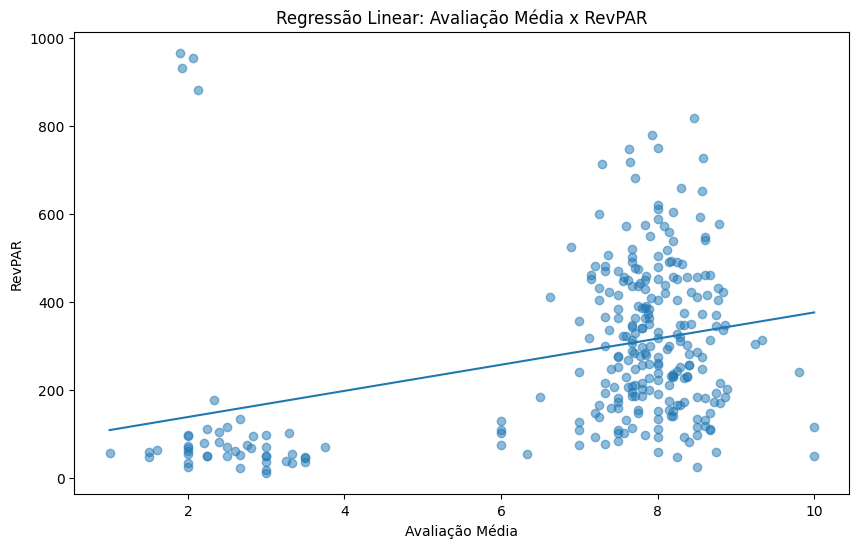

In [161]:
plt.figure(figsize=(10,6))

plt.scatter(
    df_modelo['avaliacao_hospede'],
    df_modelo['revpar'],
    alpha=0.5
)

plt.plot(
    sorted(df_modelo['avaliacao_hospede']),
    modelo.predict(
        pd.DataFrame(
            sorted(df_modelo['avaliacao_hospede']),
            columns=['avaliacao_hospede']
        )
    )
)

plt.xlabel('Avaliação Média')
plt.ylabel('RevPAR')
plt.title('Regressão Linear: Avaliação Média x RevPAR')

plt.show()

In [162]:
display(f'R²: {r2:.3f}')

display(
    f'RevPAR = {modelo.intercept_:.2f} + '
    f'{modelo.coef_[0]:.2f} × Avaliação'
)

'R²: 0.402'

'RevPAR = 79.49 + 29.68 × Avaliação'

# Problema 6

## Pergunta de Negócio

Qual região apresenta maior variabilidade no faturamento? O que isso pode indicar para a gestão comercial?

*Esta análise busca identificar as regiões que apresentam maior oscilação de faturamento ao longo do período analisado. A partir dos resultados, serão discutidas possíveis implicações para a gestão comercial e o planejamento estratégico da rede.*

In [163]:
fat_regiao = (
    df_analise
    .groupby('regiao')['faturamento']
    .sum()
    .reset_index()
)

display(fat_regiao)

,regiao,faturamento
0,Baixada Fluminense,668890.0
1,Capital,1592440.0
2,Costa Verde,1442590.0
3,Serra,1497980.0


In [164]:
variabilidade_regiao = (
    df_analise
    .groupby('regiao')['faturamento']
    .agg(
        media='mean',
        desvio_padrao='std',
        minimo='min',
        maximo='max'
    )
    .reset_index()
)

display(
    variabilidade_regiao
    .sort_values(
        'desvio_padrao',
        ascending=False
    )
)

variabilidade_regiao['cv'] = (
    variabilidade_regiao['desvio_padrao']
    / variabilidade_regiao['media']
) * 100

display(
    variabilidade_regiao
    .sort_values(
        'cv',
        ascending=False
    )
)

,regiao,media,desvio_padrao,minimo,maximo
3,Serra,2565.034247,2062.618113,280.0,10500.0
2,Costa Verde,2404.316667,1955.608398,280.0,10500.0
1,Capital,1884.544379,1793.999262,280.0,10500.0
0,Baixada Fluminense,1562.827103,1704.392369,280.0,10500.0


,regiao,media,desvio_padrao,minimo,maximo,cv
0,Baixada Fluminense,1562.827103,1704.392369,280.0,10500.0,109.058281
1,Capital,1884.544379,1793.999262,280.0,10500.0,95.195384
2,Costa Verde,2404.316667,1955.608398,280.0,10500.0,81.337389
3,Serra,2565.034247,2062.618113,280.0,10500.0,80.412888


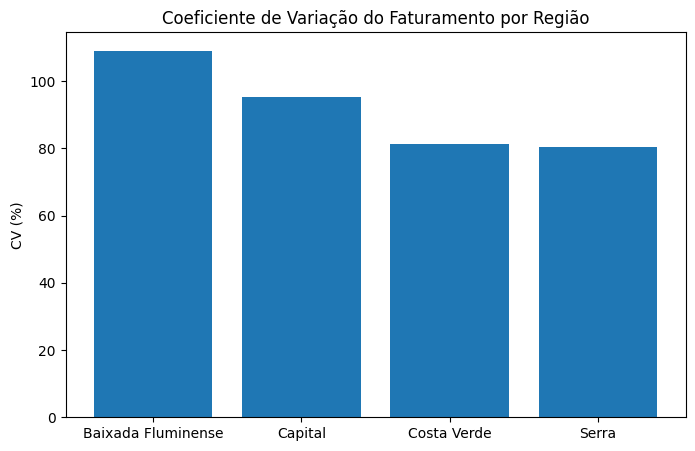

In [165]:
plt.figure(figsize=(8,5))

plt.bar(
    variabilidade_regiao['regiao'],
    variabilidade_regiao['cv']
)

plt.title(
    'Coeficiente de Variação do Faturamento por Região'
)

plt.ylabel('CV (%)')

plt.show()